# 2.5 Optimal Trading Strategies and 2.6 Performance Metrics

This notebook builds optimal trading strategies from the synthetic alpha signals, runs model-based backtests, and compiles the required performance report.

The pipeline is:

1. load test data, fitted impact parameters, and synthetic alphas;
2. build the OW alpha-driven strategy;
3. build the nonlinear AFS strategy;
4. build the round-trip TWAP benchmark using `src.backtest_engine.make_round_trip_twap_trade_df`;
5. run OW and AFS model backtests;
6. report alpha quality, PnL, Sharpe, transaction costs, drawdowns, turnover, and impact dislocation.

## 1. Imports and paths

Run this cell first after editing any helper `.py` files. It reloads the modules so the notebook does not keep stale function definitions in memory.

In [29]:
import os
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

# Make sure the local project is importable.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src.data_prep as data_prep
import src.backtest_engine as backtest_engine
import src.optimal_trading_strategies as optimal_trading_strategies

importlib.reload(data_prep)
importlib.reload(backtest_engine)
importlib.reload(optimal_trading_strategies)

from src.data_prep import *
from src.backtest_engine import *
from src.optimal_trading_strategies import *
# TWAP helpers live in backtest_engine; keep this explicit to avoid duplicate/stale definitions.
from src.backtest_engine import make_twap_trade_df, make_round_trip_twap_trade_df

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

## 2. Load outputs from previous sections

This section loads the saved outputs from Sections 2.1--2.4. The strategy is built and evaluated on the **test month**, while fitted impact parameters come from the previous fitting step.

In [30]:
# Section 2.1 outputs: price and traded-volume panels.
train_px_df = load_panel_csv(DATA_DIR / "train_px_201901_20.csv")
test_px_df = load_panel_csv(DATA_DIR / "test_px_201902_20.csv")
test_traded_volume_df = load_panel_csv(DATA_DIR / "test_traded_volume_201902_20.csv")

# Section 2.1 output: stock-level scaling variables.
scaling_df = load_stock_level_csv(DATA_DIR / "scaling_201901_20.csv")

# Section 2.2 outputs: fitted impact model parameters.
best_df = pd.read_csv(DATA_DIR / "impact_model_best_by_is_201901_train_201902_test.csv")
stock_results_df = pd.read_csv(DATA_DIR / "impact_model_stock_results_201901_train_201902_test.csv")

# Section 2.4 outputs: synthetic alpha level and diagnostics.
synthetic_alpha_df = load_panel_csv(DATA_DIR / "synthetic_alpha_201902_20.csv")
synthetic_alpha_diagnostics_df = load_stock_level_csv(DATA_DIR / "synthetic_alpha_diagnostics_201902_20.csv")

# Section 2.4 output: synthetic alpha decay. If the saved decay file is absent,
# reconstruct the lecture convention decay_t = -mu_t = -(alpha_{t+dt} - alpha_t) / dt.
synthetic_alpha_decay_path = DATA_DIR / "synthetic_alpha_decay_201902_20.csv"
if synthetic_alpha_decay_path.exists():
    synthetic_alpha_decay_df = load_panel_csv(synthetic_alpha_decay_path)
else:
    synthetic_alpha_decay_df = make_alpha_decay_df_from_alpha(synthetic_alpha_df, dt_seconds=10)

# Keep only common intraday columns across panels.
test_px_df, test_traded_volume_df, synthetic_alpha_df, synthetic_alpha_decay_df = align_intraday_columns(
    test_px_df,
    test_traded_volume_df,
    synthetic_alpha_df,
    synthetic_alpha_decay_df,
)

print("train_px_df:", train_px_df.shape)
print("test_px_df:", test_px_df.shape)
print("test_traded_volume_df:", test_traded_volume_df.shape)
print("synthetic_alpha_df:", synthetic_alpha_df.shape)
print("synthetic_alpha_decay_df:", synthetic_alpha_decay_df.shape)
print("scaling_df:", scaling_df.shape)

train_px_df: (420, 2341)
test_px_df: (380, 2341)
test_traded_volume_df: (380, 2341)
synthetic_alpha_df: (380, 2341)
synthetic_alpha_decay_df: (380, 2341)
scaling_df: (20, 2)


## 3. Reconstruct fitted model parameter tables

For each impact model, select the fitted stock-level parameter table corresponding to the half-life chosen in Section 2.2.

In [31]:
model_types = ["ow", "afs", "reduced_form"]
required_cols = ["lambda_hat", "half_life_seconds", "is_r2", "oos_r2"]

fit_dfs = {}
fit_summary_rows = []
test_stocks = set(test_px_df.index.get_level_values(0).unique())

for model_type in model_types:
    fit_df = get_best_model_fit_df(
        stock_results_df=stock_results_df,
        best_df=best_df,
        model_type=model_type,
    )

    missing_cols = [col for col in required_cols if col not in fit_df.columns]
    if missing_cols:
        raise ValueError(f"{model_type} fit_df is missing columns: {missing_cols}")

    fit_dfs[model_type] = fit_df
    missing_stocks = sorted(test_stocks - set(fit_df.index))

    fit_summary_rows.append({
        "model_type": model_type,
        "n_stocks": fit_df.shape[0],
        "selected_half_life_minutes": fit_df["half_life_seconds"].iloc[0] / 60,
        "mean_is_r2": fit_df["is_r2"].mean(),
        "mean_oos_r2": fit_df["oos_r2"].mean(),
        "n_missing_test_stocks": len(missing_stocks),
    })

fit_summary_df = pd.DataFrame(fit_summary_rows)
display(fit_summary_df.round(6))

for model_type, fit_df in fit_dfs.items():
    print(model_type)
    display(fit_df[required_cols].head())

,model_type,n_stocks,selected_half_life_minutes,mean_is_r2,mean_oos_r2,n_missing_test_stocks
0,ow,20,30.0,0.167120,0.158372,0
1,afs,20,5.0,0.153022,0.149694,0
2,reduced_form,20,10.0,0.196336,0.179360,0


ow


,lambda_hat,half_life_seconds,is_r2,oos_r2
stock,,,,
AAL,262.866026,1800,0.143934,0.199819
AAPL,407.392206,1800,0.231705,0.252164
ABBV,382.822089,1800,0.130716,0.131900
ABT,440.867448,1800,0.171972,0.115936
ADBE,339.189338,1800,0.123732,0.137870


afs


,lambda_hat,half_life_seconds,is_r2,oos_r2
stock,,,,
AAL,0.770608,300,0.151269,0.185629
AAPL,0.828313,300,0.234038,0.227081
ABBV,0.540337,300,0.102414,0.115905
ABT,0.550386,300,0.133748,0.099200
ADBE,0.573366,300,0.130973,0.123505


reduced_form


,lambda_hat,half_life_seconds,is_r2,oos_r2
stock,,,,
AAL,73.752339,600,0.181003,0.244088
AAPL,106.653594,600,0.281354,0.309429
ABBV,89.711831,600,0.151770,0.123431
ABT,99.691282,600,0.186580,0.098858
ADBE,87.620862,600,0.156239,0.175975


## 4. Strategy settings and containers

The OW strategy is kept as a raw alpha-driven OW rule. Smoothing is applied to the alpha-decay estimate to reduce finite-difference noise. The fitted half-life is not manually changed here; it comes from the calibrated model table.

In [32]:
dt_seconds = 10

# OW alpha input smoothing. The alpha level is usually already smooth; the decay estimate is much noisier.
smooth_alpha_window = None
smooth_decay_window = 40

# Optional OW risk controls. Set to None for the raw unconstrained rule.
target_impact_cap = None
max_trade_fraction_adv_per_bin = None
force_zero_close = False

# TWAP benchmark: participation_rate is one-way. 0.10 gives 20% ADV total round-trip turnover.
twap_one_way_participation = 0.10

# AFS nonlinear strategy parameters.
afs_smooth_alpha_window = 5
afs_max_fraction_adv_per_bin = 0.002
afs_turnover_penalty = 1e-4
afs_terminal_inventory_penalty = 1e-2
afs_impact_penalty_multiplier = 1.0
afs_maxiter = 300

alpha_scenarios = {}
alpha_decay_scenarios = {}
strategy_trade_dfs = {}
target_impact_dfs = {}
used_alpha_dfs = {}
used_alpha_decay_dfs = {}
strategy_diagnostic_dfs = {}

## 5. OW strategy from intraday alpha

The OW strategy maps the alpha level and alpha decay into a target impact path, then recovers trades from the fitted OW impact dynamics.

In [33]:
alpha_scenarios["intraday_only"] = synthetic_alpha_df.copy()
alpha_decay_scenarios["intraday_only"] = synthetic_alpha_decay_df.copy()

(
    ow_trades_df,
    ow_target_impact_df,
    ow_used_alpha_df,
    ow_used_alpha_decay_df,
    ow_strategy_diagnostics_df,
) = make_ow_optimal_trade_df(
    alpha_df=alpha_scenarios["intraday_only"],
    alpha_decay_df=alpha_decay_scenarios["intraday_only"],
    test_px_df=test_px_df,
    scaling_df=scaling_df,
    fit_df=fit_dfs["ow"],
    dt_seconds=dt_seconds,
    smooth_alpha_window=smooth_alpha_window,
    smooth_decay_window=smooth_decay_window,
    target_impact_cap=target_impact_cap,
    max_trade_fraction_adv_per_bin=max_trade_fraction_adv_per_bin,
    force_zero_close=force_zero_close,
)

strategy_trade_dfs["intraday_only_ow_rule"] = ow_trades_df
target_impact_dfs["intraday_only_ow_rule"] = ow_target_impact_df
used_alpha_dfs["intraday_only_ow_rule"] = ow_used_alpha_df
used_alpha_decay_dfs["intraday_only_ow_rule"] = ow_used_alpha_decay_df
strategy_diagnostic_dfs["intraday_only_ow_rule"] = ow_strategy_diagnostics_df

print("intraday_only_ow_rule")
print("  total abs traded:", ow_trades_df.abs().sum(axis=1).describe()[["mean", "50%", "min", "max"]].to_dict())
print("  net traded:", ow_trades_df.sum(axis=1).describe()[["mean", "50%", "min", "max"]].to_dict())
print("  max abs target impact:", ow_target_impact_df.abs().max(axis=1).describe()[["mean", "50%", "min", "max"]].to_dict())

display(ow_strategy_diagnostics_df.head())

intraday_only_ow_rule
  total abs traded: {'mean': 2389452.7882736376, '50%': 1061366.242506124, 'min': 611323.3203287617, 'max': 18984122.925445568}
  net traded: {'mean': 1748.747574558626, '50%': 725.393671724659, 'min': -606780.2595786366, 'max': 678869.0904830598}
  max abs target impact: {'mean': 0.004954461876587348, '50%': 0.004217813723637698, 'min': 0.001321490539239184, 'max': 0.0165784622303807}


,stock,date,ADV,sigma,lambda_hat,half_life_seconds,beta,smooth_alpha_window,smooth_decay_window,target_impact_cap,max_trade_fraction_adv_per_bin,force_zero_close,total_abs_traded,net_traded,max_abs_trade,max_abs_target_impact
0,AAL,2019-02-01,1.236722e+06,0.000528,262.866026,1800.0,0.000385,None,40,None,None,False,3.977234e+06,53933.010195,34992.630935,0.008373
1,AAL,2019-02-04,1.236722e+06,0.000528,262.866026,1800.0,0.000385,None,40,None,None,False,3.932144e+06,7748.487967,54717.511807,0.006145
2,AAL,2019-02-05,1.236722e+06,0.000528,262.866026,1800.0,0.000385,None,40,None,None,False,3.863142e+06,2116.664298,53406.048330,0.005997
3,AAL,2019-02-06,1.236722e+06,0.000528,262.866026,1800.0,0.000385,None,40,None,None,False,3.992010e+06,-39579.339895,64352.764181,0.005727
4,AAL,2019-02-07,1.236722e+06,0.000528,262.866026,1800.0,0.000385,None,40,None,None,False,3.855650e+06,32628.742375,105201.982786,0.011814


## 6. AFS nonlinear optimal strategy

The AFS strategy does not use the closed-form OW target-impact rule. It solves a numerical finite-dimensional control problem using the fitted AFS impact dynamics, trading on a coarser control grid for stability.

In [34]:
afs_trade_df, afs_impact_df, afs_diag_df = make_nonlinear_optimal_trade_df(
    alpha_df=synthetic_alpha_df,
    test_px_df=test_px_df,
    scaling_df=scaling_df,
    fit_df=fit_dfs["afs"],
    model_type="afs",
    dt_seconds=dt_seconds,
    smooth_alpha_window=afs_smooth_alpha_window,
    max_fraction_adv_per_bin=afs_max_fraction_adv_per_bin,
    turnover_penalty=afs_turnover_penalty,
    terminal_inventory_penalty=afs_terminal_inventory_penalty,
    impact_penalty_multiplier=afs_impact_penalty_multiplier,
    maxiter=afs_maxiter,
)

strategy_trade_dfs["afs_nonlinear"] = afs_trade_df

print("AFS nonlinear strategy built")
print("  total abs traded:", afs_trade_df.abs().sum(axis=1).describe()[["mean", "50%", "min", "max"]].to_dict())
print("  net traded:", afs_trade_df.sum(axis=1).describe()[["mean", "50%", "min", "max"]].to_dict())
print("  max abs fitted AFS impact:", afs_impact_df.abs().max(axis=1).describe()[["mean", "50%", "min", "max"]].to_dict())

display(afs_diag_df.head())

AFS nonlinear strategy built
  total abs traded: {'mean': 59680.26096866187, '50%': 29393.498749932965, 'min': 3284.9997171283276, 'max': 1257379.6033919477}
  net traded: {'mean': 3950.824248083706, '50%': 924.523044372708, 'min': -686257.8300444628, 'max': 1049815.266178434}
  max abs fitted AFS impact: {'mean': 0.0007966814266138573, '50%': 0.0006889776347088429, 'min': 0.00021332040095993672, 'max': 0.002792323929701469}


,success,message,objective,n_fine_controls,n_coarse_controls,control_block_size,total_abs_fraction_adv,net_fraction_adv,max_abs_fraction_per_bin,max_abs_fraction_per_block,stock,date,model_type,ADV,sigma,lambda_hat,half_life_seconds,max_fraction_adv_per_bin_input,turnover_penalty,terminal_inventory_penalty,impact_penalty_multiplier
0,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,-0.000071,2341,79,30,0.081436,0.050028,0.000208,0.006251,AAL,2019-02-01,afs,1.236722e+06,0.000528,0.770608,300.0,0.002,0.0001,0.01,1.0
1,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,-0.000003,2341,79,30,0.013952,-0.001833,0.000030,0.000911,AAL,2019-02-04,afs,1.236722e+06,0.000528,0.770608,300.0,0.002,0.0001,0.01,1.0
2,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,-0.000002,2341,79,30,0.010496,-0.000306,0.000016,0.000483,AAL,2019-02-05,afs,1.236722e+06,0.000528,0.770608,300.0,0.002,0.0001,0.01,1.0
3,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,-0.000026,2341,79,30,0.045418,-0.025521,0.000114,0.003433,AAL,2019-02-06,afs,1.236722e+06,0.000528,0.770608,300.0,0.002,0.0001,0.01,1.0
4,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,-0.000012,2341,79,30,0.023998,0.019888,0.000065,0.001952,AAL,2019-02-07,afs,1.236722e+06,0.000528,0.770608,300.0,0.002,0.0001,0.01,1.0


## 7. AFS nonlinear diagnostics

Before looking at PnL, check that the optimizer converged and that trade sizes are economically reasonable.

In [35]:
afs_optimizer_summary_df = summarize_nonlinear_diagnostics(afs_diag_df)
display(afs_optimizer_summary_df)

afs_failed_optimizations_df = find_failed_nonlinear_optimizations(afs_diag_df)
if len(afs_failed_optimizations_df) > 0:
    print("Failed AFS optimizations:")
    display(afs_failed_optimizations_df)
else:
    print("All AFS stock-day optimizations reported success.")

afs_trade_summary_df = nonlinear_trade_summary(
    trades_df=afs_trade_df,
    impact_state_df=afs_impact_df,
    diag_df=afs_diag_df,
)
display(afs_trade_summary_df.describe().round(4))

,mean,median,std,min,max
objective,-0.000047,-0.000022,0.000071,-0.000842,-0.000001
total_abs_fraction_adv,0.079230,0.056629,0.072675,0.005158,0.644067
net_fraction_adv,0.003727,0.001907,0.035128,-0.119373,0.113605
max_abs_fraction_per_bin,0.000162,0.000115,0.000146,0.000010,0.001596
max_abs_fraction_per_block,0.004868,0.003442,0.004375,0.000298,0.047873
optimizer_success_rate,1.000000,NaN,NaN,NaN,NaN


All AFS stock-day optimizations reported success.


,total_abs_traded,net_traded,max_abs_trade,max_abs_impact_state,mean_abs_impact_state,objective,total_abs_fraction_adv,net_fraction_adv,max_abs_fraction_per_bin
count,3.800000e+02,3.800000e+02,380.0000,380.0000,380.0000,380.0000,380.0000,380.0000,380.0000
mean,5.968026e+04,3.950824e+03,119.7647,0.0008,0.0003,-0.0000,0.0792,0.0037,0.0002
std,1.092140e+05,9.304313e+04,209.2608,0.0004,0.0002,0.0001,0.0727,0.0351,0.0001
min,3.285000e+03,-6.862578e+05,6.7374,0.0002,0.0001,-0.0008,0.0052,-0.1194,0.0000
25%,1.578171e+04,-8.927309e+03,33.3143,0.0005,0.0002,-0.0001,0.0327,-0.0176,0.0001
50%,2.939350e+04,9.245230e+02,60.5667,0.0007,0.0003,-0.0000,0.0566,0.0019,0.0001
75%,5.852781e+04,1.063297e+04,126.4878,0.0010,0.0004,-0.0000,0.0983,0.0246,0.0002
max,1.257380e+06,1.049815e+06,2597.8536,0.0028,0.0015,-0.0000,0.6441,0.1136,0.0016


## 8. Round-trip TWAP benchmark

The TWAP benchmark is imported from `src.backtest_engine`, not redefined in `src.optimal_trading_strategies`. It buys during the first half of the day and sells during the second half, ending approximately flat.


In [36]:
twap_round_trip_trades_df = make_round_trip_twap_trade_df(
    test_px_df=test_px_df,
    scaling_df=scaling_df,
    participation_rate=twap_one_way_participation,
)

strategy_trade_dfs["round_trip_twap"] = twap_round_trip_trades_df

print("round_trip_twap")
print("  total abs traded:", twap_round_trip_trades_df.abs().sum(axis=1).describe()[["mean", "50%", "min", "max"]].to_dict())
print("  net traded:", twap_round_trip_trades_df.sum(axis=1).describe()[["mean", "50%", "min", "max"]].to_dict())

round_trip_twap
  total abs traded: {'mean': 210496.52095238105, '50%': 86099.19523809524, 'min': 51435.32380952382, 'max': 1848185.8476190483}
  net traded: {'mean': 9.276845958083867e-12, '50%': 0.0, 'min': -1.4551915228366852e-11, 'max': 2.3283064365386963e-10}


## 9. Trade schedule diagnostics

This compares the scale of each trade schedule before backtesting. It is especially useful for distinguishing realistic strategies from mathematically unstable ones.

abs_volume_over_ADV                               net_traded_over_ADV                               max_abs_trade_over_ADV            \
                                     mean    median       min       max                mean    median       min       max                   mean    median   
strategy                                                                                                                                                     
afs_nonlinear                    0.079230  0.056629  0.005158  0.644067            0.003727  0.001907 -0.119373  0.113605               0.000162  0.000115   
intraday_only_ow_rule            2.672547  2.588189  1.488986  4.810048            0.003960  0.002190 -0.130654  0.124870               0.041108  0.034262   
round_trip_twap                  0.200000  0.200000  0.200000  0.200000           -0.000000  0.000000 -0.000000  0.000000               0.000085  0.000085   

                                           
                            min       max  
strategy                                   
afs_nonlinear          0.000010  0.001596  
intraday_only_ow_rule  0.006315  0.121286  
round_trip_twap        0.000085  0.000085

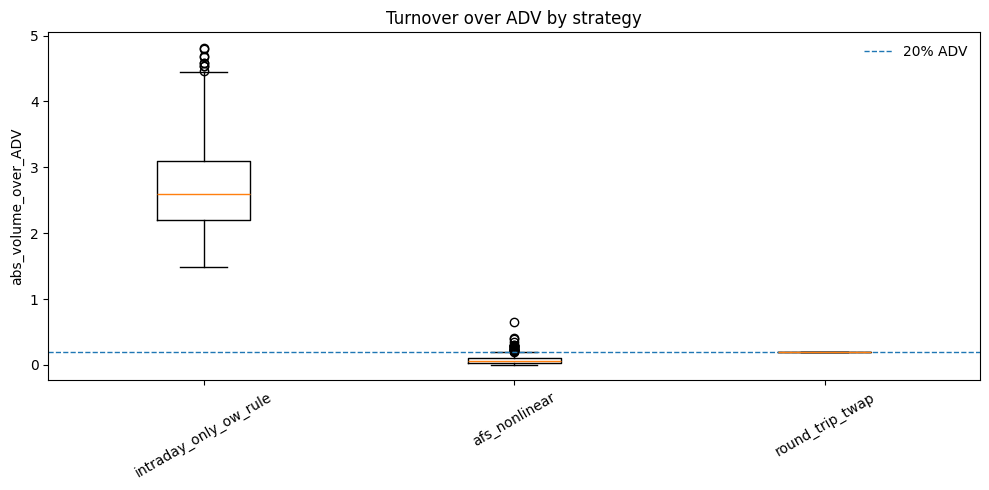

In [37]:
schedule_summary_df = trade_schedule_summary(
    strategy_trade_dfs=strategy_trade_dfs,
    scaling_df=scaling_df,
)

schedule_table = (
    schedule_summary_df
    .groupby("strategy")[["abs_volume_over_ADV", "net_traded_over_ADV", "max_abs_trade_over_ADV"]]
    .agg(["mean", "median", "min", "max"])
    .round(6)
)

display(schedule_table)
plot_turnover_boxplot(schedule_summary_df)

## 10. Backtest strategies under the OW model

This is the in-model evaluation for the OW rule plus the TWAP benchmark. The AFS strategy is also included for comparison, but remember that the market-impact simulator is OW in this section.

In [38]:
ow_backtest_trade_dfs = {
    "intraday_only_ow_rule": strategy_trade_dfs["intraday_only_ow_rule"],
    "afs_nonlinear": strategy_trade_dfs["afs_nonlinear"],
    "round_trip_twap": strategy_trade_dfs["round_trip_twap"],
}

ow_backtests_df = run_strategy_backtests_for_model(
    strategy_trade_dfs=ow_backtest_trade_dfs,
    model_type="ow",
    test_px_df=test_px_df,
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_dfs=fit_dfs,
    dt_seconds=dt_seconds,
)

print("OW backtest summary")
display(strategy_summary_table(ow_backtests_df))
display(
    ow_backtests_df
    .groupby("strategy")[["max_abs_impact", "total_abs_traded", "net_traded"]]
    .agg(["mean", "median", "std"])
    .round(4)
)

OW backtest summary


pnl_bps                   impact_cost_bps                     daily_pnl                          impact_cost                         
                          mean   median      std            mean   median      std        mean      median          std        mean      median          std
strategy                                                                                                                                                    
afs_nonlinear         -15.4082 -11.5373  33.4297         10.9183   7.2378  11.3001 -13093.8992  -2134.4450   39907.0374   8111.1034   1867.7813   17960.0970
intraday_only_ow_rule  -2.1964  -1.9681   1.1782          1.9256   1.7392   0.8685 -53968.1377 -23754.9008   84263.2367  48199.6279  21417.4865   75129.8532
round_trip_twap       -15.2826 -13.1183  27.0256         18.4491  17.0322   7.3245 -57529.7046  -7628.9256  169957.0661  59505.9769  14304.8464  134006.4219

max_abs_impact                 total_abs_traded                             net_traded                      
                                mean  median     std             mean        median           std       mean    median         std
strategy                                                                                                                          
afs_nonlinear                 0.3158  0.1270  0.7296     5.968026e+04  2.939350e+04  1.092140e+05  3950.8242  924.5230  93043.1326
intraday_only_ow_rule         0.7913  0.3247  1.6607     2.389453e+06  1.061366e+06  3.801488e+06  1748.7476  725.3937  73014.3150
round_trip_twap               0.5689  0.1751  1.4693     2.104965e+05  8.609920e+04  3.954920e+05     0.0000    0.0000      0.0000

## 11. Backtest strategies under the AFS model

This is the in-model evaluation for the AFS nonlinear strategy, with OW-rule and TWAP included as cross-model benchmarks.

In [39]:
afs_backtest_trade_dfs = {
    "afs_nonlinear": strategy_trade_dfs["afs_nonlinear"],
    "intraday_only_ow_rule": strategy_trade_dfs["intraday_only_ow_rule"],
    "round_trip_twap": strategy_trade_dfs["round_trip_twap"],
}

afs_backtests_df = run_strategy_backtests_for_model(
    strategy_trade_dfs=afs_backtest_trade_dfs,
    model_type="afs",
    test_px_df=test_px_df,
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_dfs=fit_dfs,
    dt_seconds=dt_seconds,
)

print("AFS backtest summary")
display(strategy_summary_table(afs_backtests_df))
display(
    afs_backtests_df
    .groupby("strategy")[["max_abs_impact", "total_abs_traded", "net_traded"]]
    .agg(["mean", "median", "std"])
    .round(4)
)

AFS backtest summary


pnl_bps                  impact_cost_bps                   daily_pnl                          impact_cost                        
                         mean  median      std            mean  median     std        mean      median          std        mean      median         std
strategy                                                                                                                                               
afs_nonlinear         -9.9589 -5.8476  26.9210          5.1193  4.3551  2.8266  -7119.7062   -983.4812   26857.8131   3603.0335   1242.0436   7145.0279
intraday_only_ow_rule -2.4582 -2.2359   1.2493          2.1870  1.8494  0.9891 -67718.3143 -25620.7465  106344.2251  62767.4525  21911.5059  98536.4800
round_trip_twap       -3.5824 -1.4278  25.1908          7.0022  5.9949  3.4287 -25073.7314   -776.2788  126014.8175  22672.7916   4530.4109  46788.8241

max_abs_impact                 total_abs_traded                             net_traded                      
                                mean  median     std             mean        median           std       mean    median         std
strategy                                                                                                                          
afs_nonlinear                 0.1306  0.0512  0.2777     5.968026e+04  2.939350e+04  1.092140e+05  3950.8242  924.5230  93043.1326
intraday_only_ow_rule         0.4010  0.1387  0.8559     2.389453e+06  1.061366e+06  3.801488e+06  1748.7476  725.3937  73014.3150
round_trip_twap               0.1436  0.0445  0.3438     2.104965e+05  8.609920e+04  3.954920e+05     0.0000    0.0000      0.0000

## 12. Cross-model comparison

The model used to build a strategy can advantage that strategy when the same model is used for backtesting. Cross-model comparisons help diagnose robustness to model misspecification.

In [40]:
all_backtests_df = pd.concat([ow_backtests_df, afs_backtests_df], ignore_index=True)

print("PnL bps by strategy and backtest model")
display(compare_strategy_metric_by_model(all_backtests_df, metric="pnl_bps"))

print("Impact cost bps by strategy and backtest model")
display(compare_strategy_metric_by_model(all_backtests_df, metric="impact_cost_bps"))

PnL bps by strategy and backtest model


mean           median               std         
backtest_model            afs       ow     afs       ow      afs       ow
strategy                                                                 
afs_nonlinear         -9.9589 -15.4082 -5.8476 -11.5373  26.9210  33.4297
intraday_only_ow_rule -2.4582  -2.1964 -2.2359  -1.9681   1.2493   1.1782
round_trip_twap       -3.5824 -15.2826 -1.4278 -13.1183  25.1908  27.0256

Impact cost bps by strategy and backtest model


mean           median              std         
backtest_model            afs       ow     afs       ow     afs       ow
strategy                                                                
afs_nonlinear          5.1193  10.9183  4.3551   7.2378  2.8266  11.3001
intraday_only_ow_rule  2.1870   1.9256  1.8494   1.7392  0.9891   0.8685
round_trip_twap        7.0022  18.4491  5.9949  17.0322  3.4287   7.3245

## 13. Main cumulative plots

These plots aggregate across stocks by date and strategy.

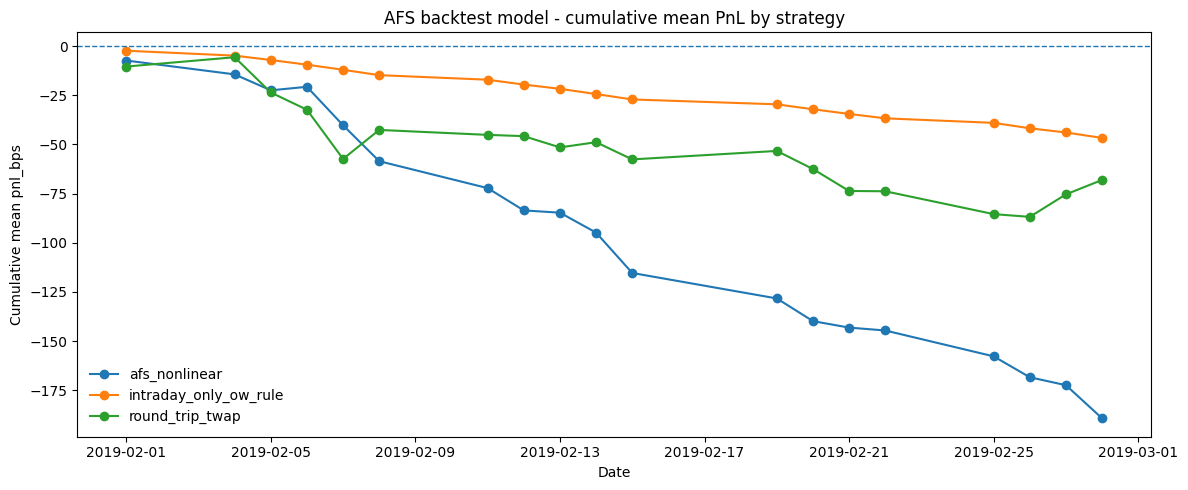

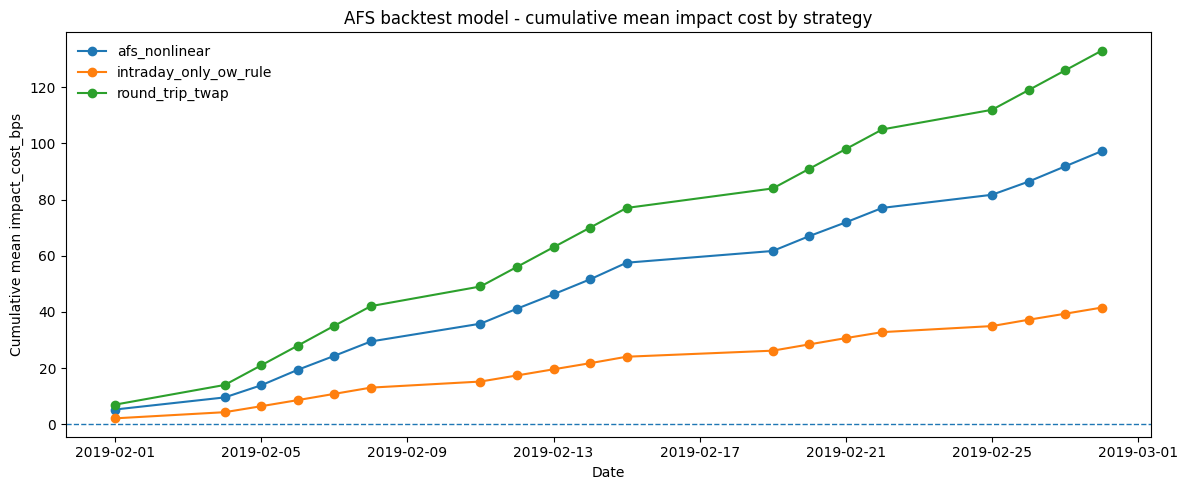

In [47]:
# Choose the backtest model you want to plot most prominently.
main_backtests_df = afs_backtests_df.copy()

cum_pnl_df = plot_strategy_cumulative_metric(
    main_backtests_df,
    metric="pnl_bps",
    title="AFS backtest model - cumulative mean PnL by strategy",
)

cum_impact_df = plot_strategy_cumulative_metric(
    main_backtests_df,
    metric="impact_cost_bps",
    title="AFS backtest model - cumulative mean impact cost by strategy",
)

## 14. One-stock-day OW diagnostic

This diagnostic explains how the OW alpha and alpha decay are transformed into target impact, trades, inventory, and realized own impact for one stock-day.

C:\Users\rapha\AppData\Local\Temp\ipykernel_15780\713589821.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax5.legend(frameon=False)


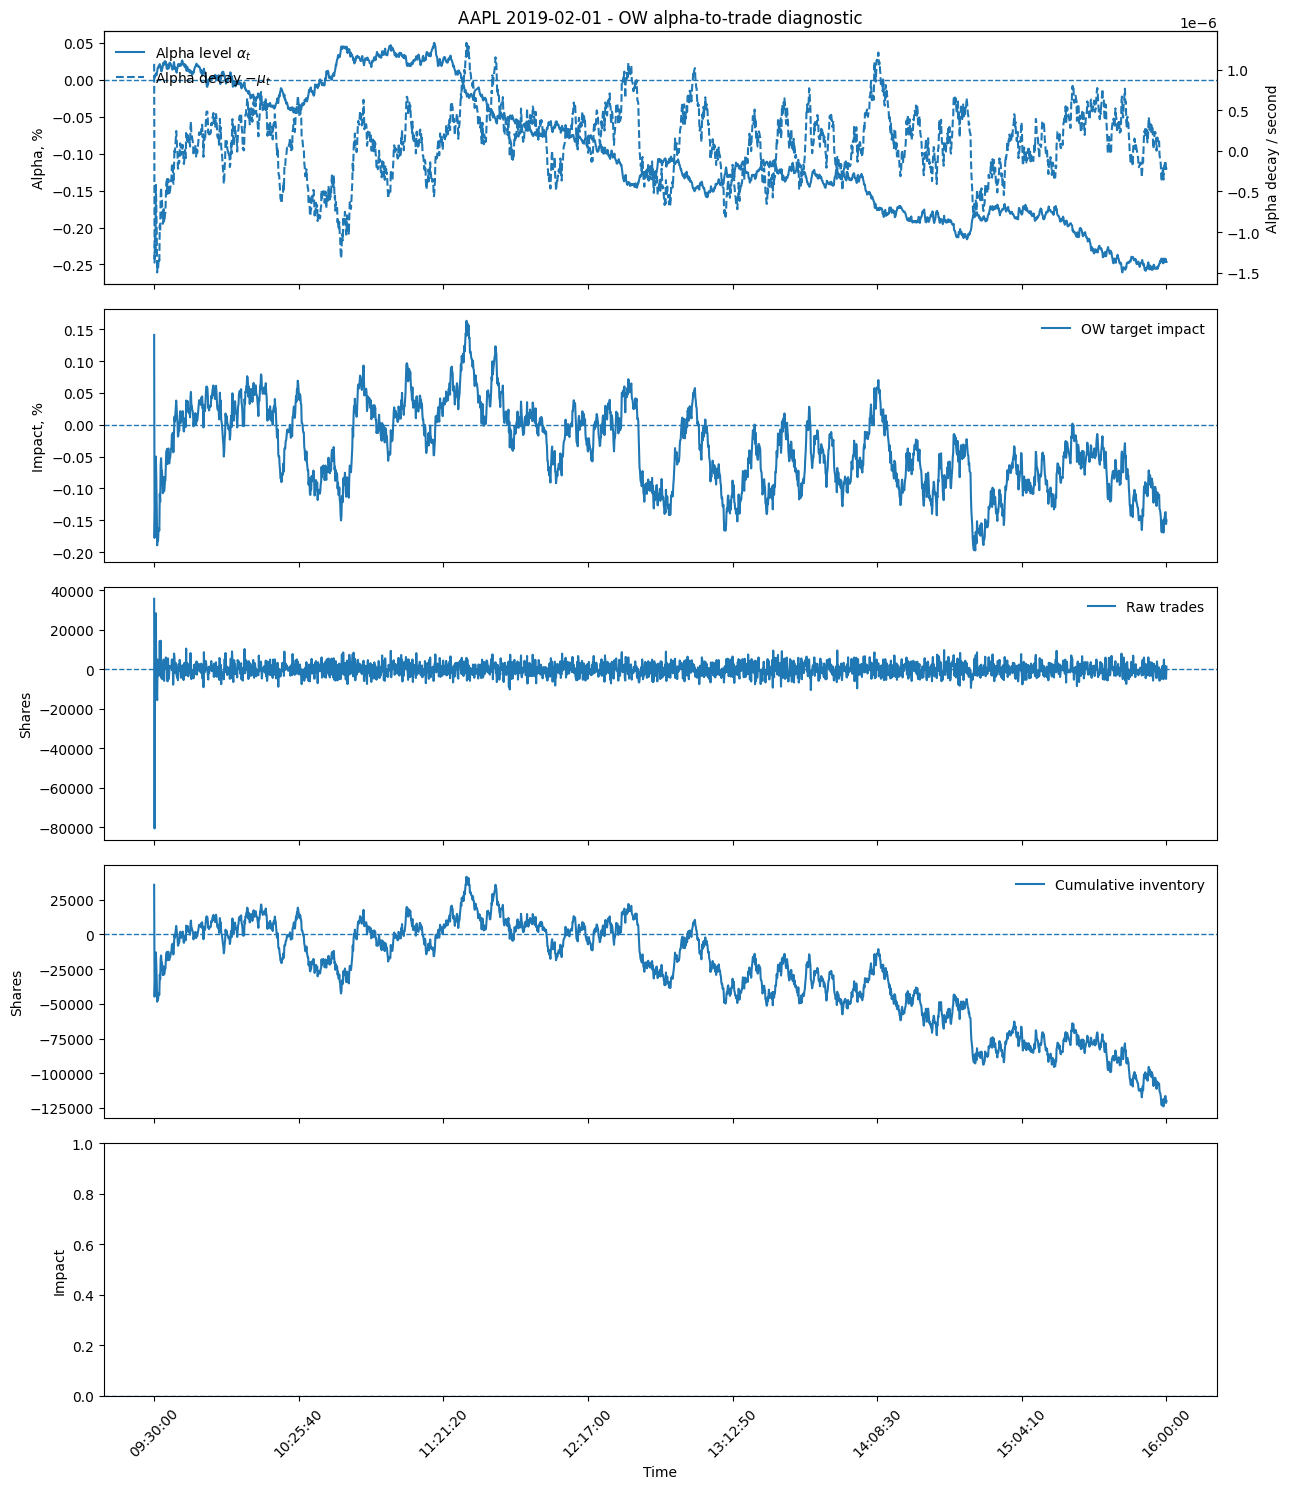

,daily_pnl,impact_cost,max_abs_impact,final_position,total_abs_traded,net_traded,avg_price,traded_notional,model_type,stock,date,lambda_hat,ADV,sigma,half_life_seconds
intraday_only_ow_rule,-93801.584525,137239.417182,0.329336,-120019.445607,6247926.891412,-120019.445607,167.348726,1045582605.801174,ow,AAPL,2019-02-01,407.392206,2968462.809524,0.000288,1800.0


In [42]:
stock = "AAPL"
if stock in test_px_df.index.get_level_values("stock"):
    date = test_px_df.loc[stock].index[0]
else:
    stock, date = test_px_df.index[0]

scenario_name = "intraday_only_ow_rule"

alpha_one = used_alpha_dfs[scenario_name].loc[(stock, date)]
alpha_decay_one = used_alpha_decay_dfs[scenario_name].loc[(stock, date)]
I_star_one = target_impact_dfs[scenario_name].loc[(stock, date)]
trades_one = strategy_trade_dfs[scenario_name].loc[(stock, date)]
position_one = trades_one.cumsum()

paths, summary_df = run_one_stock_day_paths_for_strategies(
    stock=stock,
    date=date,
    strategy_trade_dfs={scenario_name: strategy_trade_dfs[scenario_name]},
    model_type="ow",
    test_px_df=test_px_df,
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_dfs=fit_dfs,
    dt_seconds=dt_seconds,
)
path = paths[scenario_name]

x = np.arange(len(alpha_one))
tick_positions = np.linspace(0, len(alpha_one) - 1, 8, dtype=int)
tick_labels = alpha_one.index[tick_positions]

fig, axes = plt.subplots(5, 1, figsize=(13, 15), sharex=True)

ax1 = axes[0]
line1 = ax1.plot(x, 100 * alpha_one.values, label=r"Alpha level $\alpha_t$")
ax1.axhline(0, linestyle="--", linewidth=1)
ax1.set_ylabel("Alpha, %")
ax1.set_title(f"{stock} {date} - OW alpha-to-trade diagnostic")
ax1b = ax1.twinx()
line2 = ax1b.plot(x, alpha_decay_one.values, linestyle="--", label=r"Alpha decay $-\mu_t$")
ax1b.set_ylabel("Alpha decay / second")
lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, frameon=False, loc="upper left")

ax2 = axes[1]
ax2.plot(x, 100 * I_star_one.values, label="OW target impact")
if "own_impact" in path.columns:
    ax2.plot(x, 100 * path["own_impact"].values, linestyle="--", label="Realized own impact")
ax2.axhline(0, linestyle="--", linewidth=1)
ax2.set_ylabel("Impact, %")
ax2.legend(frameon=False)

ax3 = axes[2]
ax3.plot(x, trades_one.values, label="Raw trades")
ax3.axhline(0, linestyle="--", linewidth=1)
ax3.set_ylabel("Shares")
ax3.legend(frameon=False)

ax4 = axes[3]
ax4.plot(x, position_one.values, label="Cumulative inventory")
ax4.axhline(0, linestyle="--", linewidth=1)
ax4.set_ylabel("Shares")
ax4.legend(frameon=False)

ax5 = axes[4]
if "own_impact_price" in path.columns:
    ax5.plot(x, path["own_impact_price"].values, label="Own price impact")
elif "own_impact" in path.columns:
    ax5.plot(x, path["own_impact"].values, label="Own impact")
ax5.axhline(0, linestyle="--", linewidth=1)
ax5.set_ylabel("Impact")
ax5.set_xlabel("Time")
ax5.legend(frameon=False)

axes[-1].set_xticks(tick_positions)
axes[-1].set_xticklabels(tick_labels, rotation=45)
plt.tight_layout()
plt.show()

display(summary_df)

# 2.6 Performance Metrics

This section compiles the required performance report: alpha correlation with returns, expected daily PnL, Sharpe ratio, transaction costs, maximum daily drawdown, and maximum impact dislocation.

## 2.6.1 Alpha correlation with returns

The information coefficient is computed as the pooled correlation between alpha and next-bin returns.

c:\Users\rapha\OneDrive\Imperial\Quant Trading\src\optimal_trading_strategies.py:1196: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  returns = price_df.pct_change(axis=1).shift(-1, axis=1)


Pooled alpha IC: 0.003178


c:\Users\rapha\OneDrive\Imperial\Quant Trading\src\optimal_trading_strategies.py:1196: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  returns = price_df.pct_change(axis=1).shift(-1, axis=1)


count    19.000000
mean      0.003283
std       0.003634
min      -0.003387
25%       0.000990
50%       0.002777
75%       0.006374
max       0.008999
Name: ic, dtype: float64

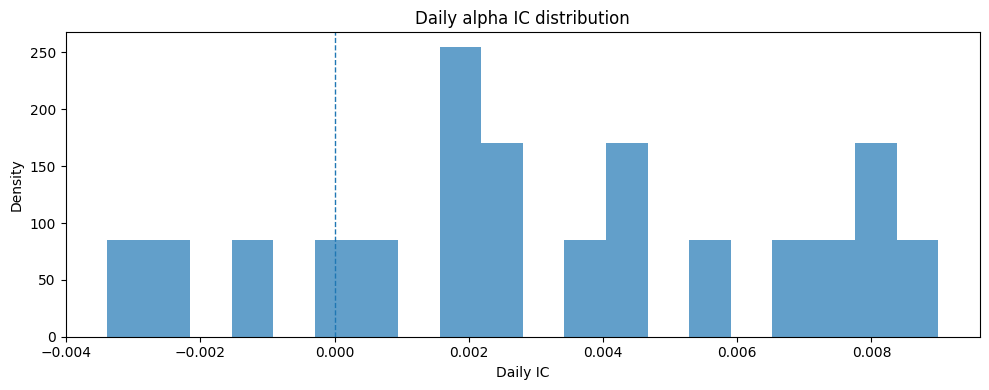

In [43]:
pooled_ic, alpha_return_pairs = alpha_return_correlation(
    alpha_df=alpha_scenarios["intraday_only"],
    price_df=test_px_df,
    method="pearson",
)

print(f"Pooled alpha IC: {pooled_ic:.6f}")

daily_ic_df = alpha_ic_by_day(
    alpha_df=alpha_scenarios["intraday_only"],
    price_df=test_px_df,
    method="pearson",
)

display(daily_ic_df["ic"].describe().round(6))

plt.figure(figsize=(10, 4))
plt.hist(daily_ic_df["ic"].dropna(), bins=20, density=True, alpha=0.7)
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Daily alpha IC distribution")
plt.xlabel("Daily IC")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

## 2.6.2 Strategy performance summary

The table below aggregates stock-day rows to strategy-date portfolio rows before computing Sharpe, drawdown, hit rate, and expected daily PnL.

In [44]:
# Choose the backtest universe to report. For the AFS nonlinear strategy section,
# afs_backtests_df is the main in-model evaluation. all_backtests_df gives the robustness comparison.
performance_backtests_df = afs_backtests_df.copy()

performance_summary_df = strategy_performance_summary(
    performance_backtests_df,
    aggregate_by_date=True,
)

display(performance_summary_df.round(4))

n_days  mean_daily_pnl  median_daily_pnl  std_daily_pnl  mean_pnl_bps  median_pnl_bps  std_pnl_bps  sharpe_bps  \
backtest_model strategy                                                                                                                                
afs            round_trip_twap            19   -5.014746e+05     -3.181710e+05    756154.6310       -3.5824         -2.5167       9.9989     -5.6875   
               afs_nonlinear              19   -1.423941e+05     -1.275638e+05    116584.9289       -9.9589        -10.6305       6.4242    -24.6088   
               intraday_only_ow_rule      19   -1.354366e+06     -1.347757e+06    158292.9648       -2.4582         -2.4669       0.2078   -187.7700   

                                      hit_rate  max_daily_drawdown  final_cumulative_pnl  mean_impact_cost_bps  median_impact_cost_bps  std_impact_cost_bps  \
backtest_model strategy                                                                                                                                       
afs            round_trip_twap          0.2105       -8.200332e+06         -9.528018e+06                7.0022                  6.9975               0.0259   
               afs_nonlinear            0.1053       -2.281998e+06         -2.705488e+06                5.1193                  5.1470               0.5389   
               intraday_only_ow_rule    0.0000       -2.429694e+07         -2.573296e+07                2.1870                  2.1744               0.0483   

                                      mean_turnover  median_turnover  std_turnover  mean_max_abs_impact  median_max_abs_impact  std_max_abs_impact  \
backtest_model strategy                                                                                                                              
afs            round_trip_twap         4.209930e+06     4.209930e+06        0.0000               0.1436                 0.1437              0.0015   
               afs_nonlinear           1.193605e+06     1.152097e+06   363977.4508               0.1306                 0.1251              0.0229   
               intraday_only_ow_rule   4.778906e+07     4.791778e+07   736997.2164               0.4010                 0.4002              0.0435   

                                      max_impact_dislocation  
backtest_model strategy                                       
afs            round_trip_twap                        0.1456  
               afs_nonlinear                          0.1717  
               intraday_only_ow_rule                  0.4587

## 2.6.3 PnL, transaction cost, drawdown, and distribution plots

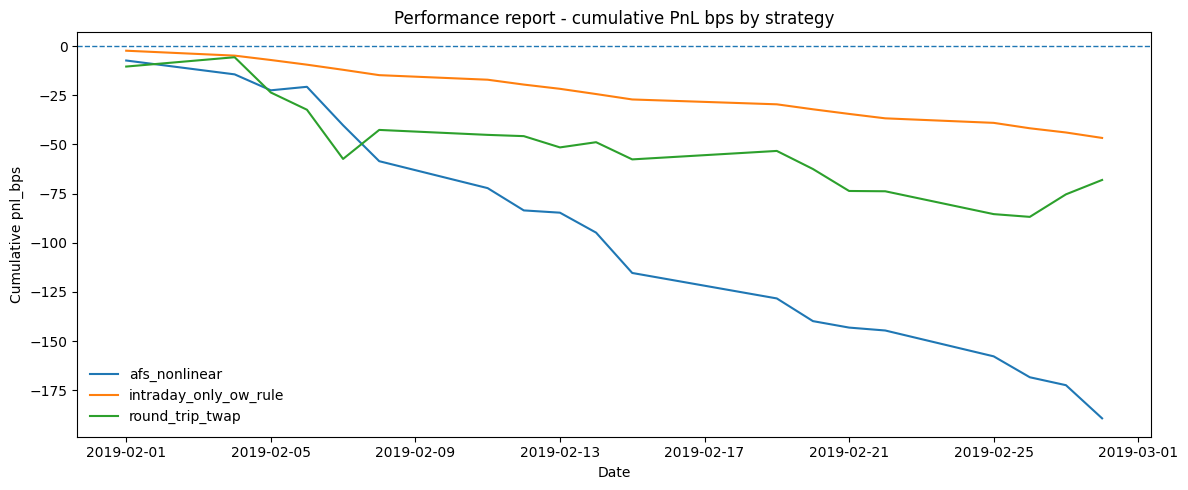

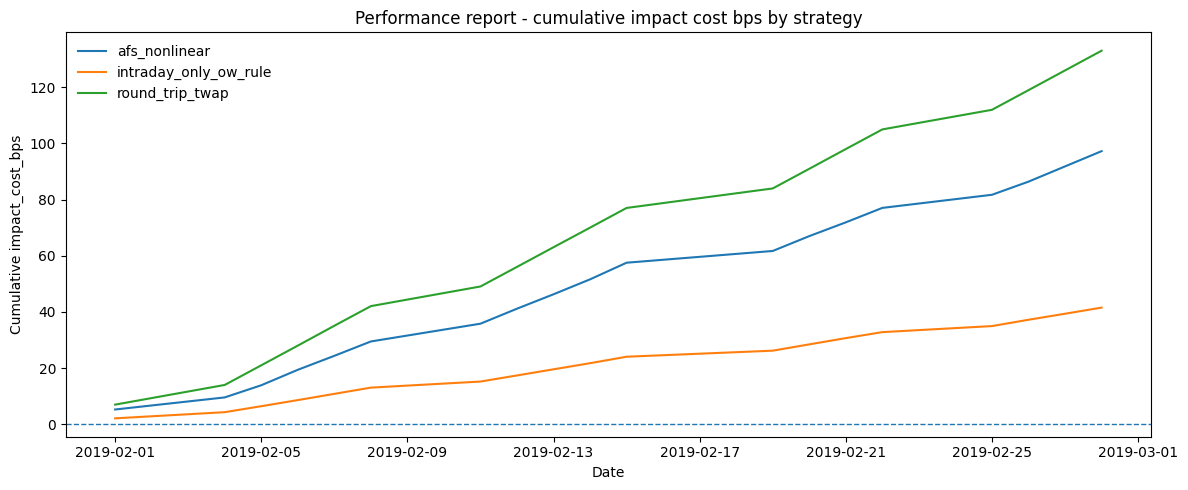

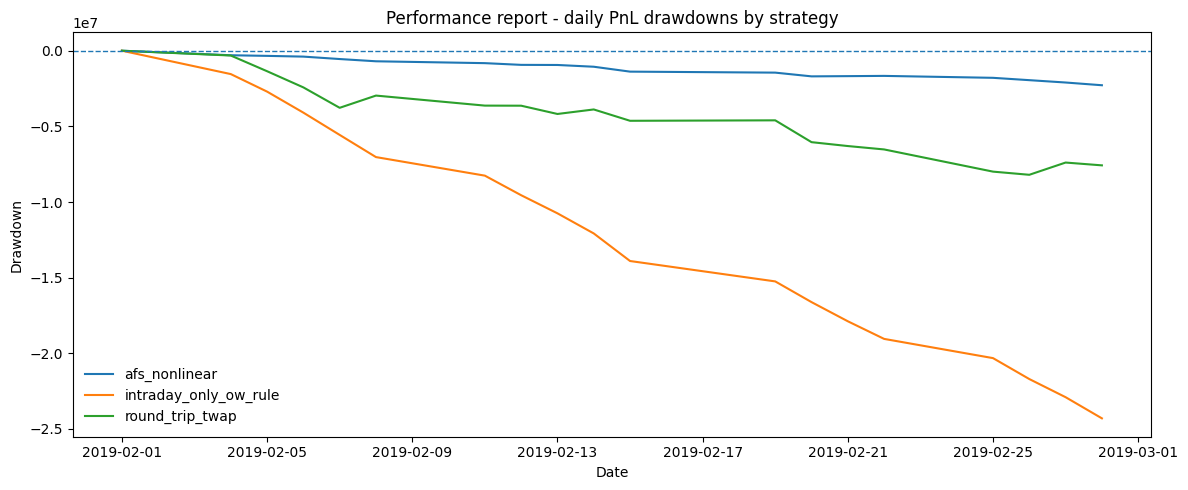

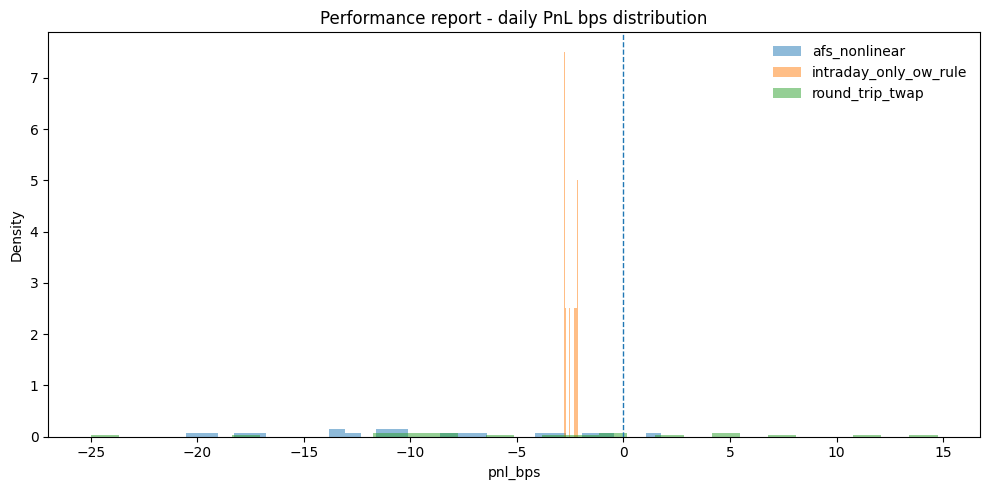

In [45]:
performance_cum_pnl_df = plot_cumulative_pnl(
    performance_backtests_df,
    value_col="pnl_bps",
    title="Performance report - cumulative PnL bps by strategy",
)

performance_cum_impact_df = plot_cumulative_impact_cost(
    performance_backtests_df,
    value_col="impact_cost_bps",
    title="Performance report - cumulative impact cost bps by strategy",
)

performance_drawdowns_df = plot_drawdowns(
    performance_backtests_df,
    value_col="daily_pnl",
    title="Performance report - daily PnL drawdowns by strategy",
)

plot_daily_pnl_distribution(
    performance_backtests_df,
    value_col="pnl_bps",
    bins=30,
    title="Performance report - daily PnL bps distribution",
)

## 2.6.4 Cross-model performance report

This table reports the same metrics separately for each backtest model. It helps show whether a strategy only works inside the model under which it was designed.

In [46]:
cross_model_performance_summary_df = strategy_performance_summary(
    all_backtests_df,
    aggregate_by_date=True,
)

display(cross_model_performance_summary_df.round(4))

n_days  mean_daily_pnl  median_daily_pnl  std_daily_pnl  mean_pnl_bps  median_pnl_bps  std_pnl_bps  sharpe_bps  \
backtest_model strategy                                                                                                                                
afs            round_trip_twap            19   -5.014746e+05     -3.181710e+05    756154.6310       -3.5824         -2.5167       9.9989     -5.6875   
               afs_nonlinear              19   -1.423941e+05     -1.275638e+05    116584.9289       -9.9589        -10.6305       6.4242    -24.6088   
ow             round_trip_twap            19   -1.150594e+06     -1.132712e+06    668364.1832      -15.2826        -15.5676       9.8314    -24.6762   
               afs_nonlinear              19   -2.618780e+05     -2.391310e+05    157912.6552      -15.4082        -12.6326       7.6584    -31.9384   
               intraday_only_ow_rule      19   -1.079363e+06     -1.023103e+06    196451.9429       -2.1964         -2.0998       0.2588   -134.7282   
afs            intraday_only_ow_rule      19   -1.354366e+06     -1.347757e+06    158292.9648       -2.4582         -2.4669       0.2078   -187.7700   

                                      hit_rate  max_daily_drawdown  final_cumulative_pnl  mean_impact_cost_bps  median_impact_cost_bps  std_impact_cost_bps  \
backtest_model strategy                                                                                                                                       
afs            round_trip_twap          0.2105       -8.200332e+06         -9.528018e+06                7.0022                  6.9975               0.0259   
               afs_nonlinear            0.1053       -2.281998e+06         -2.705488e+06                5.1193                  5.1470               0.5389   
ow             round_trip_twap          0.0000       -1.994568e+07         -2.186129e+07               18.4491                 18.4406               0.0640   
               afs_nonlinear            0.0000       -4.369720e+06         -4.975682e+06               10.9183                 10.6885               2.6057   
               intraday_only_ow_rule    0.0000       -1.957473e+07         -2.050789e+07                1.9256                  1.8883               0.1395   
afs            intraday_only_ow_rule    0.0000       -2.429694e+07         -2.573296e+07                2.1870                  2.1744               0.0483   

                                      mean_turnover  median_turnover  std_turnover  mean_max_abs_impact  median_max_abs_impact  std_max_abs_impact  \
backtest_model strategy                                                                                                                              
afs            round_trip_twap         4.209930e+06     4.209930e+06        0.0000               0.1436                 0.1437              0.0015   
               afs_nonlinear           1.193605e+06     1.152097e+06   363977.4508               0.1306                 0.1251              0.0229   
ow             round_trip_twap         4.209930e+06     4.209930e+06        0.0000               0.5689                 0.5692              0.0057   
               afs_nonlinear           1.193605e+06     1.152097e+06   363977.4508               0.3158                 0.2561              0.1198   
               intraday_only_ow_rule   4.778906e+07     4.791778e+07   736997.2164               0.7913                 0.7672              0.1499   
afs            intraday_only_ow_rule   4.778906e+07     4.791778e+07   736997.2164               0.4010                 0.4002              0.0435   

                                      max_impact_dislocation  
backtest_model strategy                                       
afs            round_trip_twap                        0.1456  
               afs_nonlinear                          0.1717  
ow             round_trip_twap                        0.5767  
               afs_nonlinear    

## 2.6.5 Key interpretation points

We need to interepret the results of this section
